In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils._param_validation import InvalidParameterError

import config

from pathlib import Path
import warnings
import joblib

import pandas as pd

import kagglehub

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning

from xgboost.sklearn import XGBClassifier

In [2]:
#TODO

# Filter outliers
# Improve Hyper-Parameters
# Save best model

In [3]:
RANDOM_SEED = 673458346

In [4]:
pio.renderers.default = "png"

## 1.0 Data Preprocessing

### 1.1 Loading and Inspecting Data

In [5]:
# Download the latest version of the dataset
path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
# Load dataset into a DataFrame
df = pd.read_csv(Path(path) / 'creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

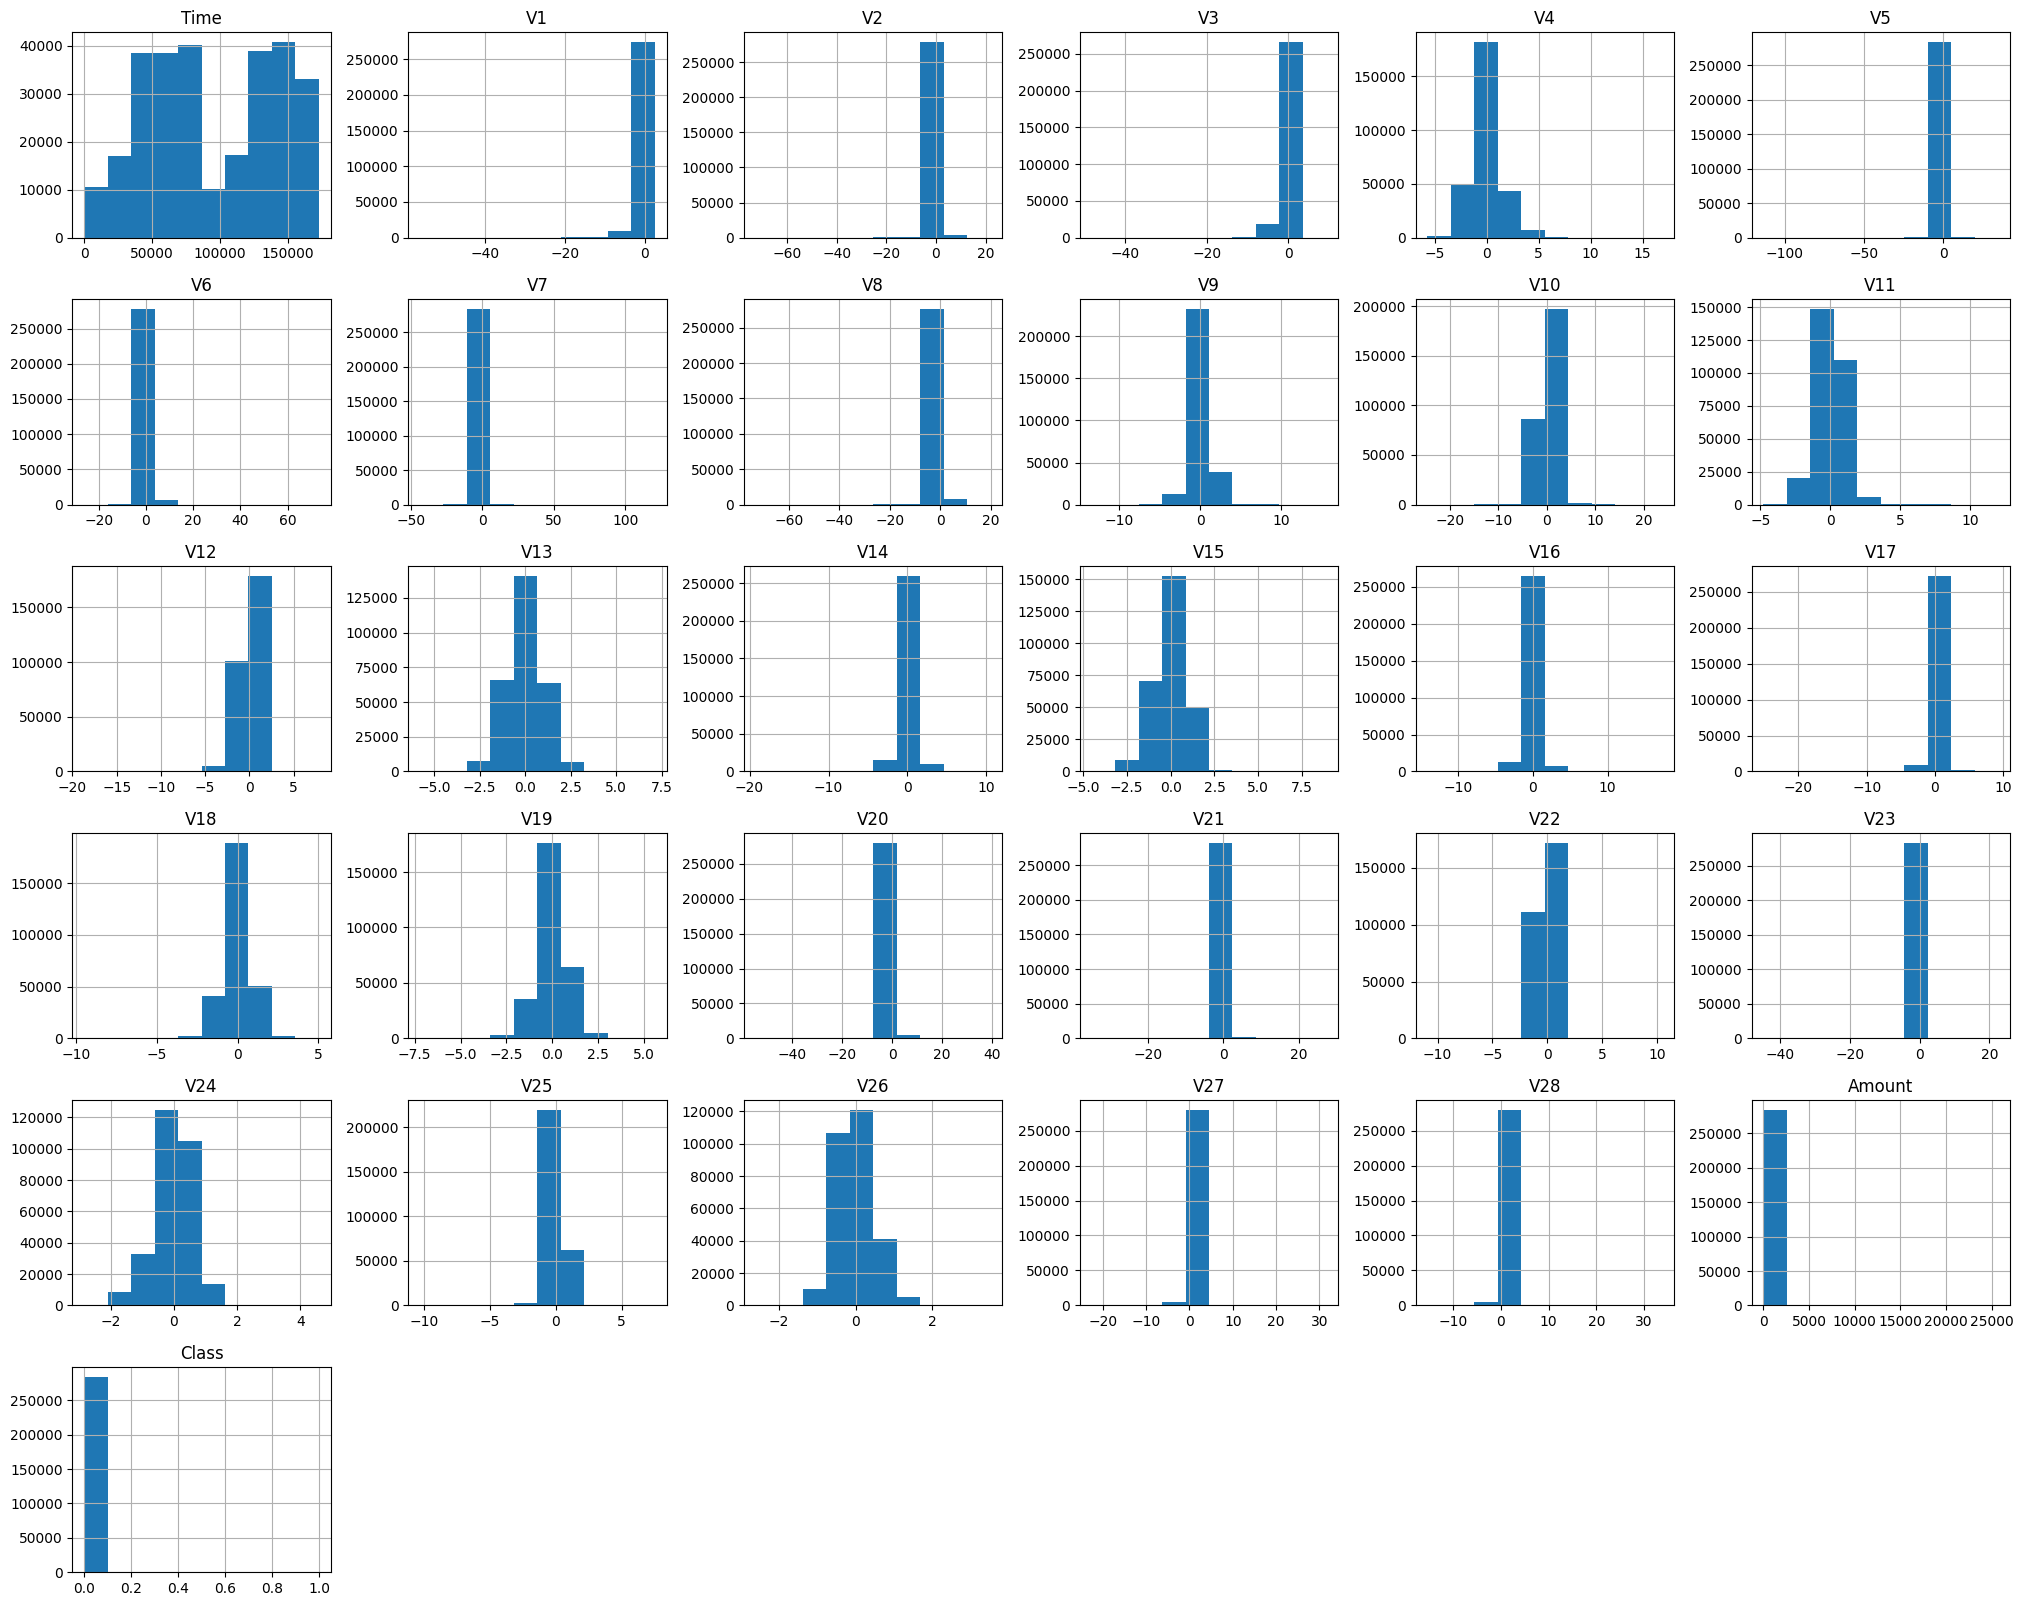

In [7]:
df.hist(figsize=(25, 20))

In [8]:
# Check class distribution
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


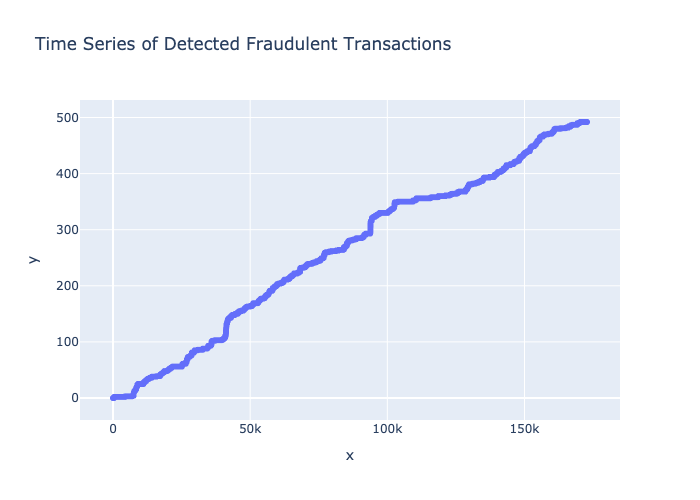

In [9]:
fig = px.scatter(x=df['Time'], y=df['Class'].cumsum(), title=f'Time Series of Detected Fraudulent Transactions')
fig.show()

In [10]:
df = df.drop('Time', axis=1)

### 1.2 Train test Split

In [11]:
# Split into train and test sets before upsampling
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class', axis=1),
                                                    df['Class'],
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED,
                                                    stratify=df['Class'])

### 1.3 Scaling and Transforming Features

In [12]:
# Normalize non-normalized columns
#scaler = RobustScaler()
scaler = StandardScaler()
# Fitting the scaler on the training data and transforming the training data
X_train.loc[:] = scaler.fit_transform(X_train)
# Using the fitted scaler on the test data
X_test.loc[:]  = scaler.transform(X_test)

X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
52363,-2.017357,2.083243,-1.062871,0.791032,-1.881306,-0.366404,-1.973585,2.732110,-0.772223,-1.146100,...,-1.121270,0.311344,-0.695954,0.449341,-0.256207,0.044662,-1.064250,-3.892628,-0.988093,-0.336907
266078,-0.262682,-0.345584,1.396300,-2.216011,-0.588144,0.255113,-0.504854,0.114945,-1.529480,0.249368,...,-0.304628,-0.270036,-0.207375,-0.620274,-1.680930,0.953034,-0.303737,0.180849,0.171263,-0.255049
23738,-0.467706,0.583590,1.273691,-1.074617,-0.012524,-0.626246,0.762342,-0.291484,0.306933,0.431891,...,0.588929,-0.241885,-0.004450,-0.197112,0.941484,-0.653653,1.328631,0.346058,-0.462202,-0.346194
105980,0.777502,-0.635476,0.329048,-1.019385,-1.118909,-0.487208,-0.912475,-0.100377,-1.488688,1.307472,...,-0.422980,-0.549607,-1.162804,0.186036,-0.304602,0.343852,-0.784687,0.094206,0.073910,-0.276358
268753,1.014030,-0.650958,-0.597531,-0.141138,-0.521396,-0.047134,-0.446876,-0.041488,-0.065421,0.705733,...,-0.619449,-0.927184,-1.722464,0.400254,-0.656466,-0.573402,0.814985,-0.102059,-0.180388,-0.080600


array([[<Axes: title={'center': 'V1'}>, <Axes: title={'center': 'V2'}>,
        <Axes: title={'center': 'V3'}>, <Axes: title={'center': 'V4'}>,
        <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>],
       [<Axes: title={'center': 'V11'}>, <Axes: title={'center': 'V12'}>,
        <Axes: title={'center': 'V13'}>, <Axes: title={'center': 'V14'}>,
        <Axes: title={'center': 'V15'}>],
       [<Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>,
        <Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>],
       [<Axes: title={'center': 'V21'}>, <Axes: title={'center': 'V22'}>,
        <Axes: title={'center': 'V23'}>, <Axes: title={'center': 'V24'}>,
        <Axes: title={'center': 'V25'}>],
       [<Axes: title={'center': 'V26'}>, <Axes: title={'cen

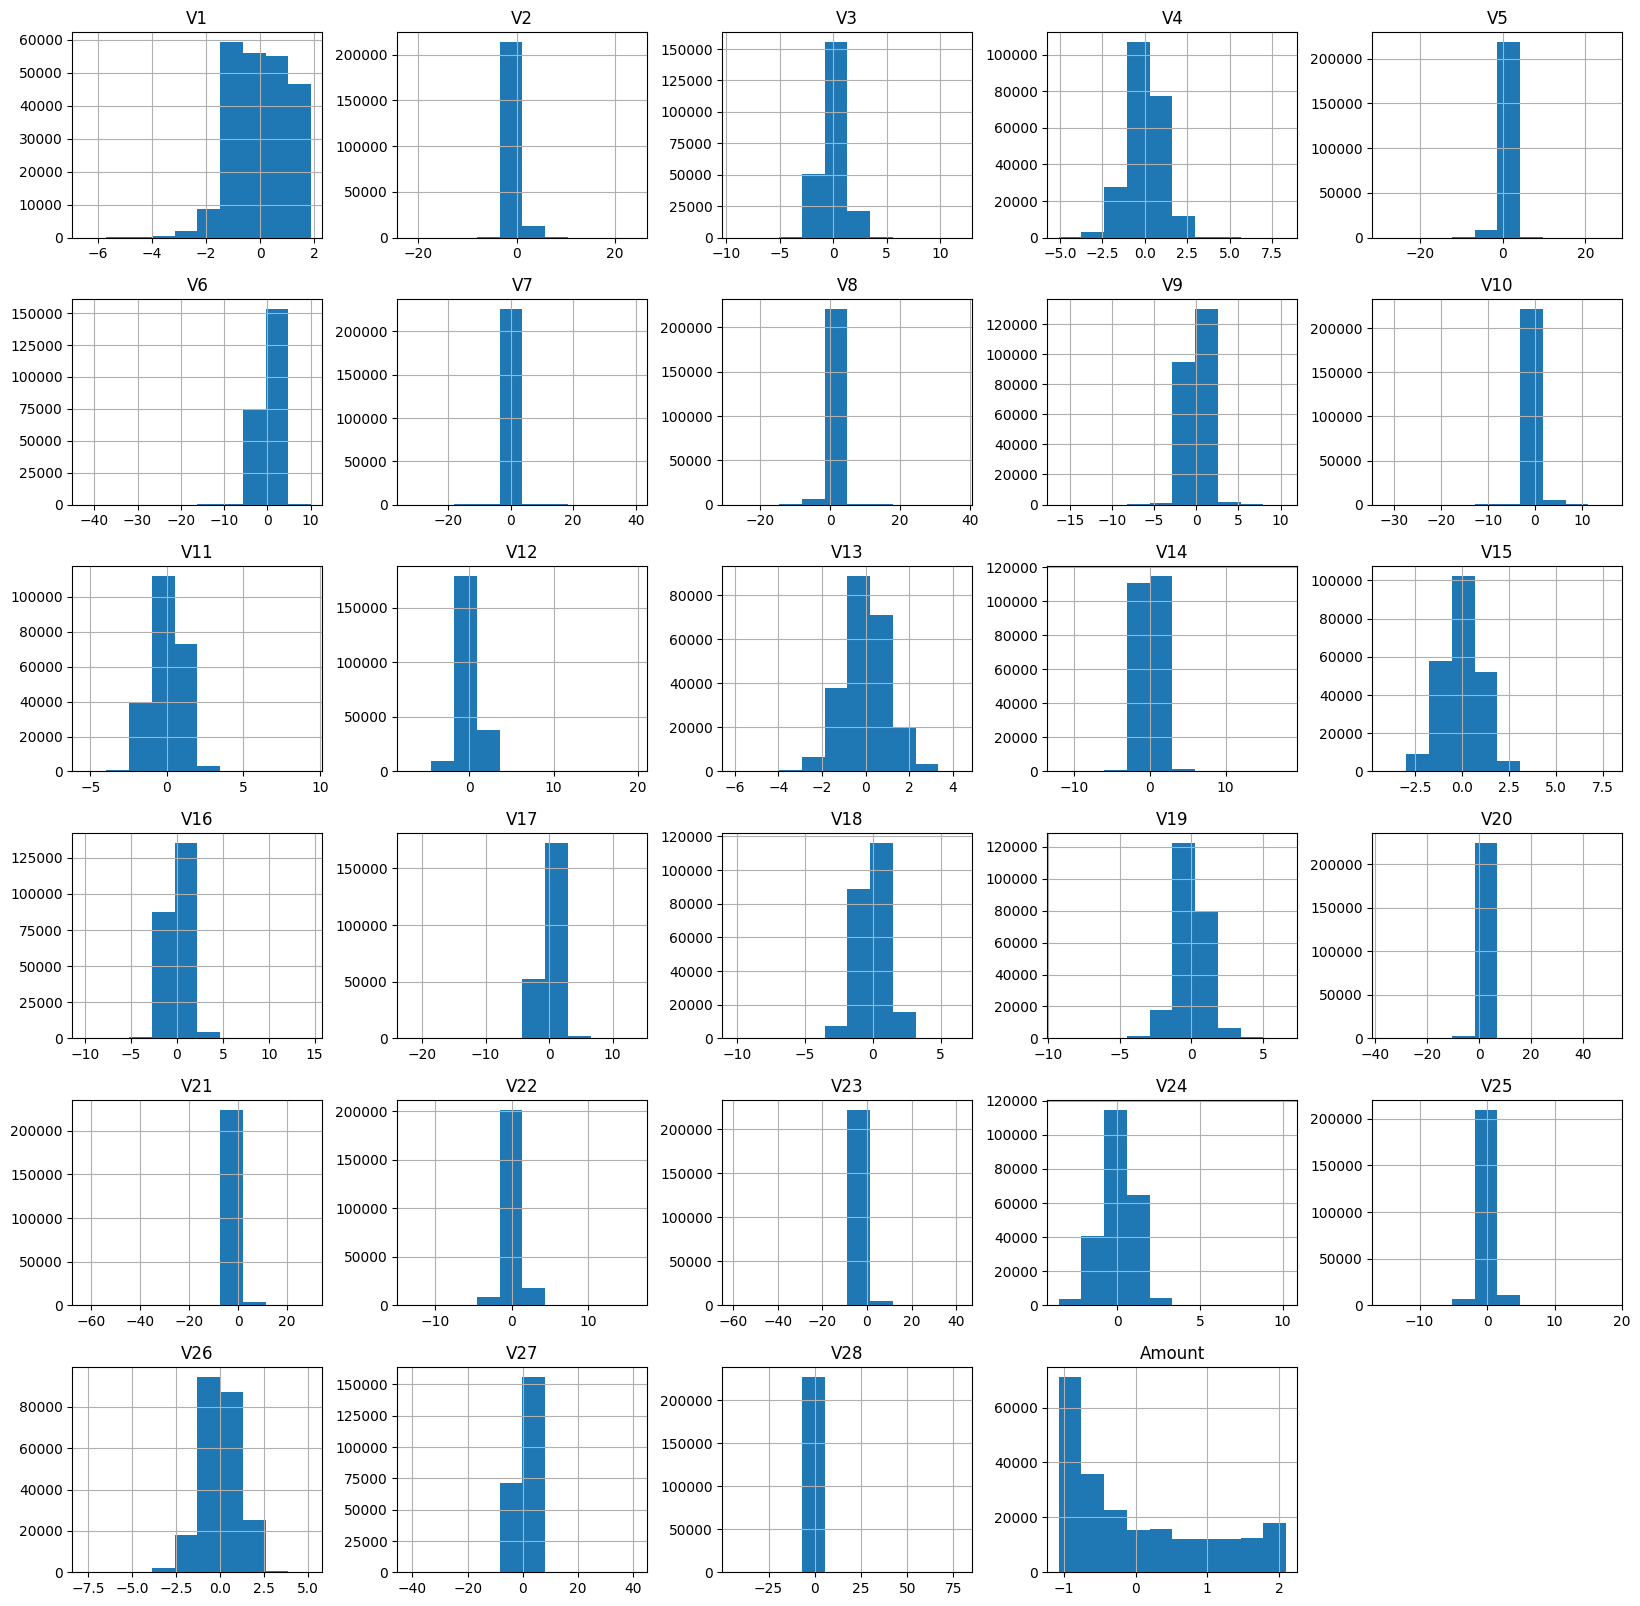

In [13]:
# Transform features to be normally distributed
transformer = PowerTransformer(method="yeo-johnson")

X_train.loc[:] = transformer.fit_transform(X_train)
X_test.loc[:] = transformer.transform(X_test)
X_train.hist(figsize=(20, 20))

### 1.4 Balancing the Dataset
We are choosing to up-sample the under-represent class in the training data as well downsample the over-represented class. We will only re-sample the training data and not the test data. When using an up-sampling technique it is important to do this after the train test split to avoid duplicated samples appearing in both the training and test sets.

In [14]:
dataset_size = 10_000

train_df = pd.concat([X_train, y_train], axis=1)
fraud_train = train_df[train_df['Class'] == 1]
non_fraud_train = train_df[train_df['Class'] == 0]

fraud_upsampled = resample(fraud_train, replace=True, n_samples=int(dataset_size/2), random_state=RANDOM_SEED)
non_fraud_downsampled = resample(non_fraud_train, replace=False, n_samples=int(dataset_size/2), random_state=RANDOM_SEED)

train_balanced = pd.concat([non_fraud_downsampled, fraud_upsampled]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

X_train_balanced = train_balanced.drop('Class', axis=1)
y_train_balanced = train_balanced['Class']

print(y_train_balanced.value_counts())

Class
0    5000
1    5000
Name: count, dtype: int64


## 2.0 Model Training

First, we define a dictionary containing the various models we wish to train. These are all common, supervised classifiers.

In [15]:
model_dict = {
    'Logistic Regression Model': LogisticRegression(max_iter=5000, n_jobs=-1, random_state=RANDOM_SEED),
    'Random Forest Model': RandomForestClassifier(n_jobs=-1, random_state=RANDOM_SEED),
    'XGBoost Model': XGBClassifier(eval_metric='logloss', n_jobs=-1, random_state=RANDOM_SEED),
    'SVC Model': SVC(random_state=RANDOM_SEED)
              }

Next, for each model, we define the parameter grids we wish to search when performing hyper-parameter tunning.

In [16]:
param_grid_dict = {
    'Logistic Regression Model': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'saga'],
        'penalty': ['l1', 'l2']
    },
    'Random Forest Model': {
        'n_estimators': [50, 100, 200, 500],
        'max_depth': [None, 10, 20, 30, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost Model': {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 6, 9],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'SVC Model': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4]  # Only for ‘poly’ kernel
    }
}


Here we define the hyperparameter search methodology. We have opted for the comparatively fast RandomizedSearchCV due to the size of the dataset and the number of models that are being compared. We have used f1 score as our scoring function and are using 5-fold cross-validation.

In [17]:
search_dict = {
    model_name: RandomizedSearchCV(
        model,
        param_grid_dict[model_name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1,
        n_iter=20,
        refit=True,
        random_state=RANDOM_SEED
    ) for model_name, model in model_dict.items()
}

We then train each model on the balanced dataset. Warning generated due to incompatible parameter combinations have been suppressed.

In [18]:
warnings.filterwarnings('ignore', category=FitFailedWarning)
warnings.simplefilter('ignore', category=UserWarning)

for model_name, model in search_dict.items():
    print(f'training {model_name} ...')
    model.fit(X_train_balanced, y_train_balanced)


training Logistic Regression Model ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
training Random Forest Model ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
training XGBoost Model ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
training SVC Model ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [19]:
model_dict = {
    model_name: search.best_estimator_ for model_name, search in search_dict.items()
}

## 3.0 Model Evaluation

In [20]:
def try_probability(model):
    try:
        return model.predict_proba(X_test)[:, 1]
    except AttributeError:
        return None

predict_dict = {
    model_name: (model.predict(X_test), try_probability(model))
    for model_name, model in model_dict.items()
}

In [21]:
metrics = []

for name, (prediction, prob_prediction) in predict_dict.items():

    acc = accuracy_score(y_test, prediction)
    prec = precision_score(y_test, prediction, average='binary')
    rec = recall_score(y_test, prediction, average='binary')
    f1 = f1_score(y_test, prediction, average='binary')
    roc_auc = roc_auc_score(y_test, prob_prediction) if prob_prediction is not None else None

    metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

pd.DataFrame(metrics)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression Model,0.980882,0.073947,0.877551,0.136400,0.984699
1,Random Forest Model,0.998824,0.620155,0.816327,0.704846,0.982554
2,XGBoost Model,0.997999,0.455056,0.826531,0.586957,0.986234
3,SVC Model,0.990818,0.135506,0.806122,0.232012,NaN


In [22]:
conf_matrices = {model_name: confusion_matrix(y_test, predict) for model_name, (predict, predict_prob) in predict_dict.items()}

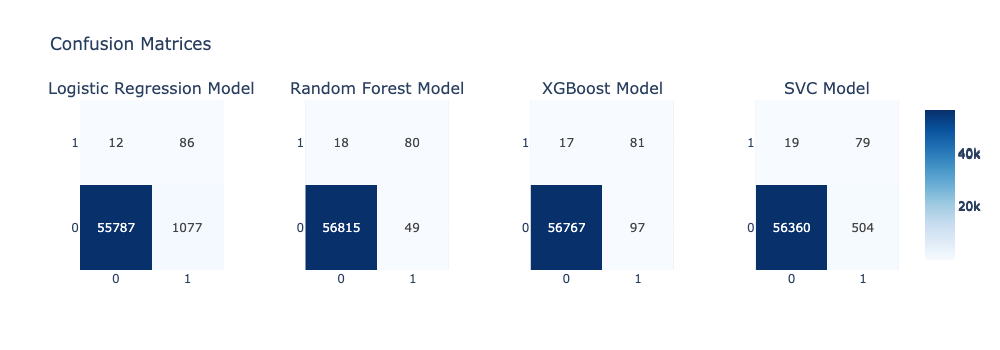

In [23]:
num_matrices = len(conf_matrices)
num_rows = len(conf_matrices) // 4

fig = make_subplots(rows=num_rows, cols=num_matrices, subplot_titles=list(conf_matrices.keys()), horizontal_spacing=0.1)

for i, (model_name, conf_matrix) in enumerate(conf_matrices.items()):

    annotations = [[str(value) for value in row] for row in conf_matrix]

    heatmap = go.Heatmap(
        z=conf_matrix,
        text=annotations,
        texttemplate="%{text}",
        colorscale="Blues",
        showscale=True
    )

    fig.add_trace(heatmap, row=1, col=i+1)

    fig.update_xaxes(
        tickmode="array", tickvals=list(range(conf_matrix.shape[1])),
        row=1, col=i+1
    )
    fig.update_yaxes(
        tickmode="array", tickvals=list(range(conf_matrix.shape[0])),
        row=1, col=i+1
    )

fig.update_layout(title="Confusion Matrices", height=350 * num_rows, width=250 * 4)

fig.show()

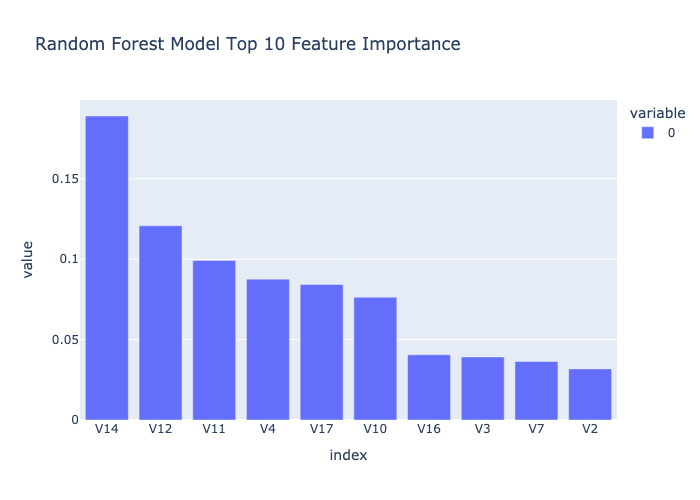

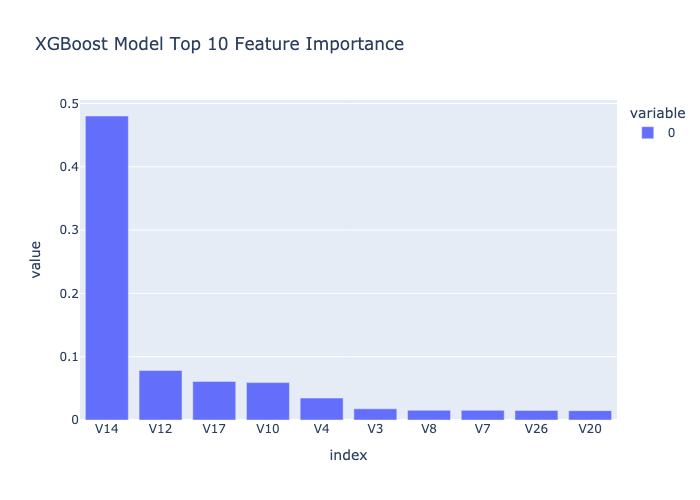

In [24]:
# Plot feature importance using Plotly
for model_name, model in model_dict.items():
    try:
        feature_importances = pd.Series(model.feature_importances_, index=X_train_balanced.columns)
        fig = px.bar(feature_importances.nlargest(10), title=f'{model_name} Top 10 Feature Importance')
        fig.show()
    except AttributeError:
        pass

## 4.0 Saving and Exporting the Model

In [25]:
# Create a pipeline for feature scaling and transformation
deploy_model = model_dict['Random Forest Model']

model_pipeline = Pipeline([
    ('scaler', scaler),
    ('power_transform', transformer),
    ('classifier', deploy_model)
])

# Save the pipeline
joblib.dump(model_pipeline, config.DEPLOY_MODEL_PATH)

['models/deploy.pkl']